# CL Spectral Evolution: Waterfall and Heat Map Analysis

Advanced visualization of 30 CL spectra showing spectral evolution with beam energy using waterfall plots and heat maps.

## Import Required Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec

# Set style for better plots
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

## Load and Prepare CL Data

In [22]:
# Load data
df = pd.read_csv('CL_data.csv', skiprows=[1])
energy = pd.to_numeric(df.iloc[:, 0]).values
spectra = df.iloc[:, 1:31].apply(pd.to_numeric).values

# Create beam energy labels (assuming 1-30 keV range)
beam_energies = np.arange(1, 31)  # 1 to 30 keV

print(f"Loaded {spectra.shape[1]} spectra")
print(f"Energy range: {energy[0]:.2f}-{energy[-1]:.2f} eV")
print(f"Beam energy range: {beam_energies[0]}-{beam_energies[-1]} keV")
print(f"Intensity range: {np.min(spectra):.2e} to {np.max(spectra):.2e}")

Loaded 30 spectra
Energy range: 1.01-4.00 eV
Beam energy range: 1-30 keV
Intensity range: 3.04e-30 to 3.85e+03


## Low Energy Waterfall Plot (1-15 keV)

Showing every 3rd spectrum to avoid overcrowding while maintaining clear progression.

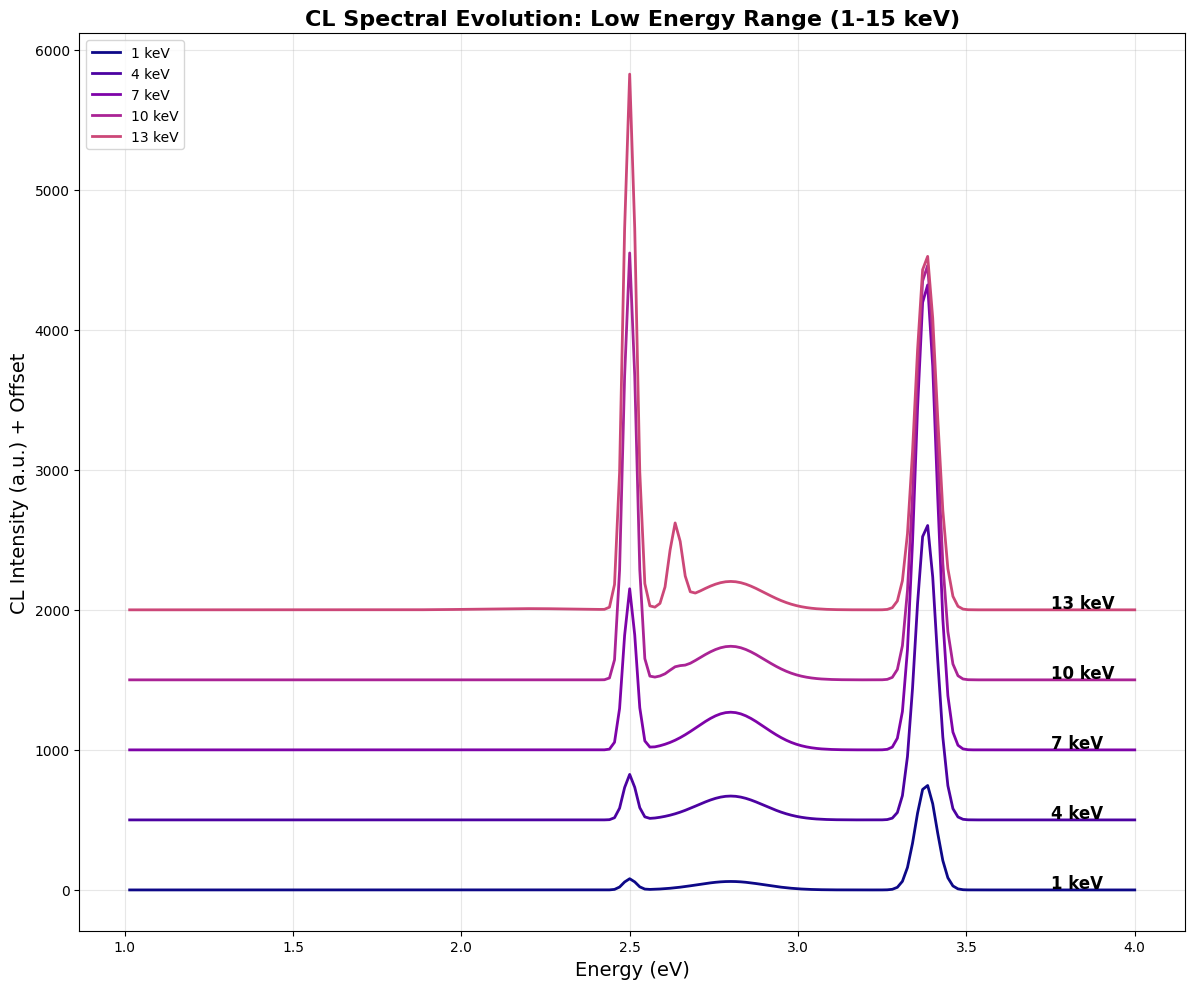

In [32]:
fig, ax = plt.subplots(figsize=(14, 10))

# Select every 3rd spectrum from 1-15 keV (indices 0, 3, 6, 9, 12)
selected_indices = np.arange(0, 15, 3)
offset_spacing = 500  # Vertical offset between spectra

# Use plasma colormap for color progression
colors = plt.cm.plasma(np.linspace(0, 0.5, len(selected_indices)))

for i, idx in enumerate(selected_indices):
    offset = i * offset_spacing
    beam_energy = beam_energies[idx]
    
    # Plot spectrum with offset
    ax.plot(energy, spectra[:, idx] + offset, 
           color=colors[i], linewidth=2, 
           label=f'{beam_energy} keV')
    
    # Add beam energy label on the right - align with the offset baseline
    ax.text(energy[-1] - 0.25, offset + 50, 
           f'{beam_energy} keV', 
           fontsize=12, fontweight='bold',
           va='center', ha='left')

ax.set_xlabel('Energy (eV)', fontsize=14)
ax.set_ylabel('CL Intensity (a.u.) + Offset', fontsize=14)
ax.set_title('CL Spectral Evolution: Low Energy Range (1-15 keV)', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

# Adjust layout to accommodate labels
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

## High Energy Waterfall Plot (15-30 keV)

Showing every 3rd spectrum from the high energy range.

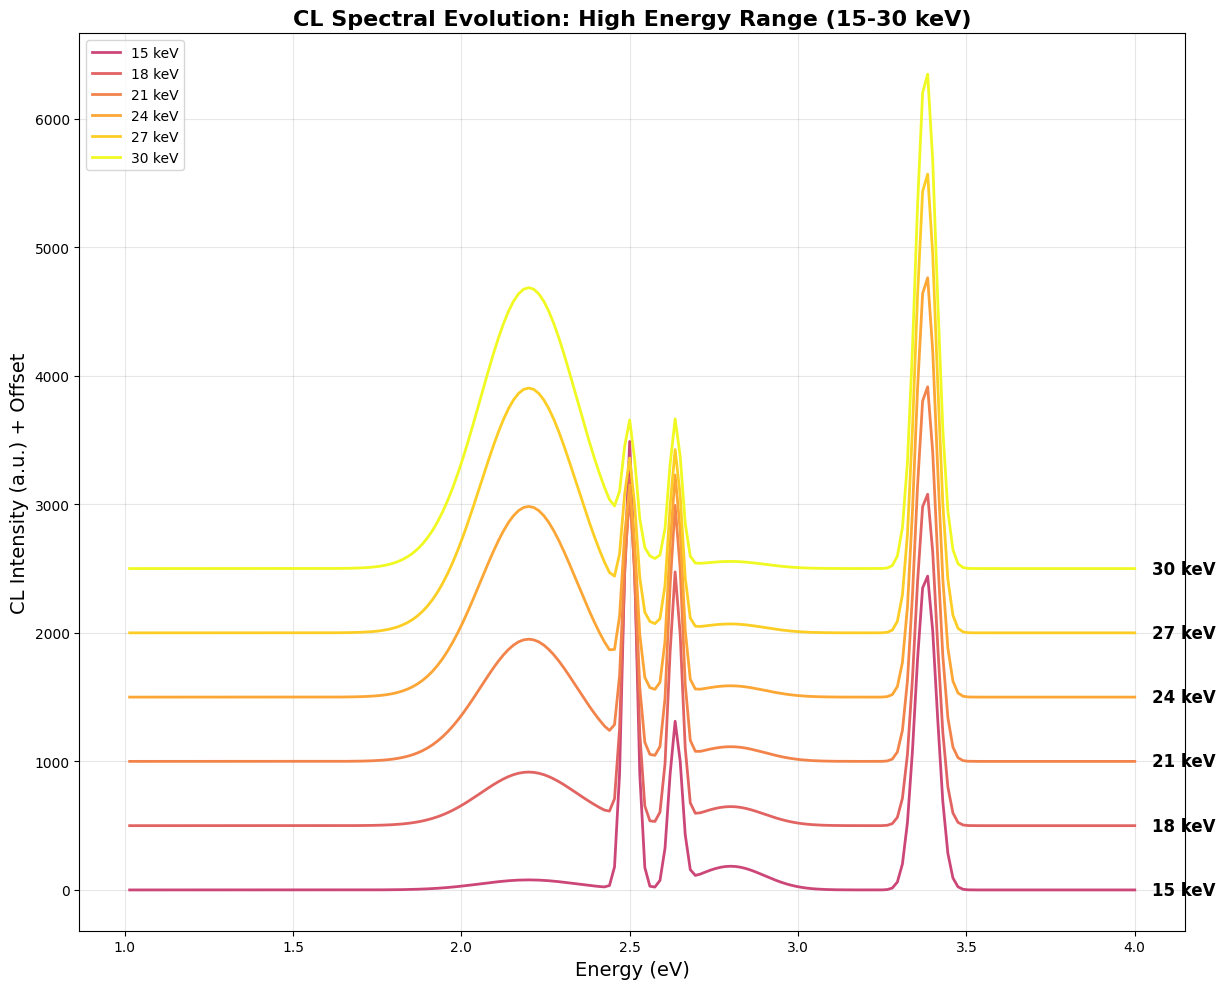

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

# Select every 3rd spectrum from 15-30 keV (indices 14, 17, 20, 23, 26, 29)
selected_indices = np.arange(14, 30, 3)
offset_spacing = 500  # Vertical offset between spectra

# Use second half of plasma colormap for color progression
colors = plt.cm.plasma(np.linspace(0.5, 1.0, len(selected_indices)))

for i, idx in enumerate(selected_indices):
    offset = i * offset_spacing
    beam_energy = beam_energies[idx]
    
    # Plot spectrum with offset
    ax.plot(energy, spectra[:, idx] + offset, 
           color=colors[i], linewidth=2, 
           label=f'{beam_energy} keV')
    
    # Add beam energy label on the right - align with the offset baseline
    ax.text(energy[-1] + 0.05, offset + 00, 
           f'{beam_energy} keV', 
           fontsize=12, fontweight='bold',
           va='center', ha='left')

ax.set_xlabel('Energy (eV)', fontsize=14)
ax.set_ylabel('CL Intensity (a.u.) + Offset', fontsize=14)
ax.set_title('CL Spectral Evolution: High Energy Range (15-30 keV)', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

# Adjust layout to accommodate labels
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

## Representative Spectra with Offset Stacking

Key representative spectra showing major trends across the full beam energy range.

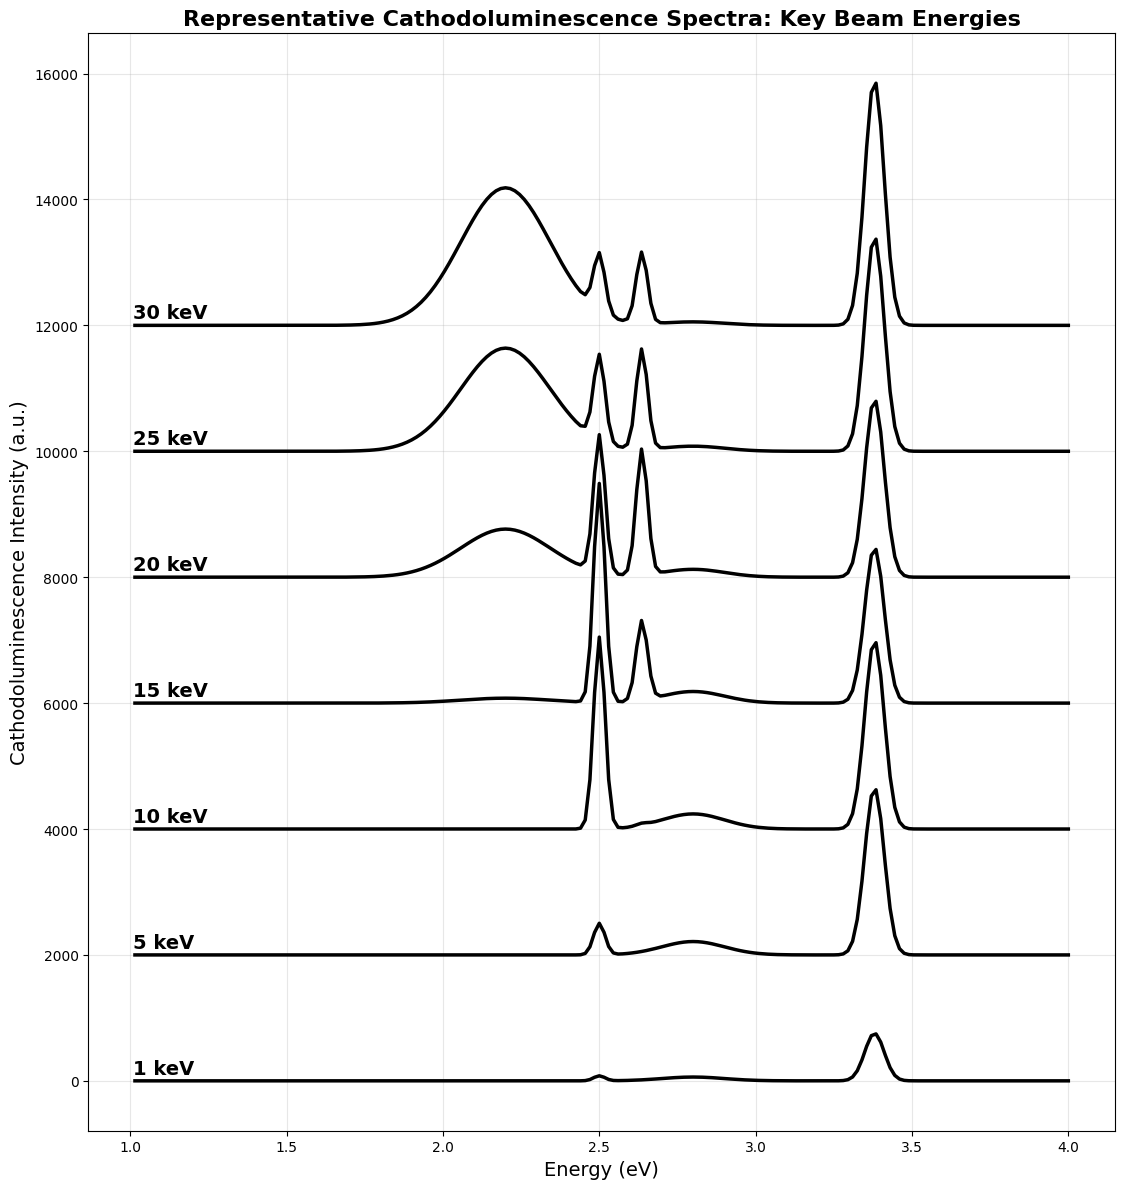

In [59]:
fig, ax = plt.subplots(figsize=(14, 12))

# Select key representative spectra (1, 5, 10, 15, 20, 25, 30 keV)
key_energies = [1, 5, 10, 15, 20, 25, 30]
key_indices = [e - 1 for e in key_energies]  # Convert to 0-based indices
offset_spacing = 2000  # Larger offset for better visibility

# Use full plasma colormap for maximum color variation
colors = plt.cm.plasma(np.linspace(0, 1, len(key_indices)))

for i, idx in enumerate(key_indices):
    offset = i * offset_spacing
    beam_energy = beam_energies[idx]
    
    # Plot spectrum with offset
    ax.plot(energy, spectra[:, idx] + offset, 
           color="black", linewidth=2.5, 
           label=f'{beam_energy} keV')
    
    # Add prominent beam energy labels - black and aligned
    ax.text(energy[-1] - 2.99, offset + 200, 
           f'{beam_energy} keV', 
           fontsize=14, fontweight='bold',
           va='center', ha='left',
           color='black',
       #     bbox=dict(boxstyle='round,pad=0.3', 
              #       facecolor='white', edgecolor='black', alpha=0.8)
    )

ax.set_xlabel('Energy (eV)', fontsize=14)
ax.set_ylabel('Cathodoluminescence Intensity (a.u.)', fontsize=14)
ax.set_title('Representative Cathodoluminescence Spectra: Key Beam Energies', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

# Adjust layout to accommodate labels
plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.show()

## Representative Spectra - Normal Plot

Same key representative spectra plotted without offsets for direct intensity comparison.

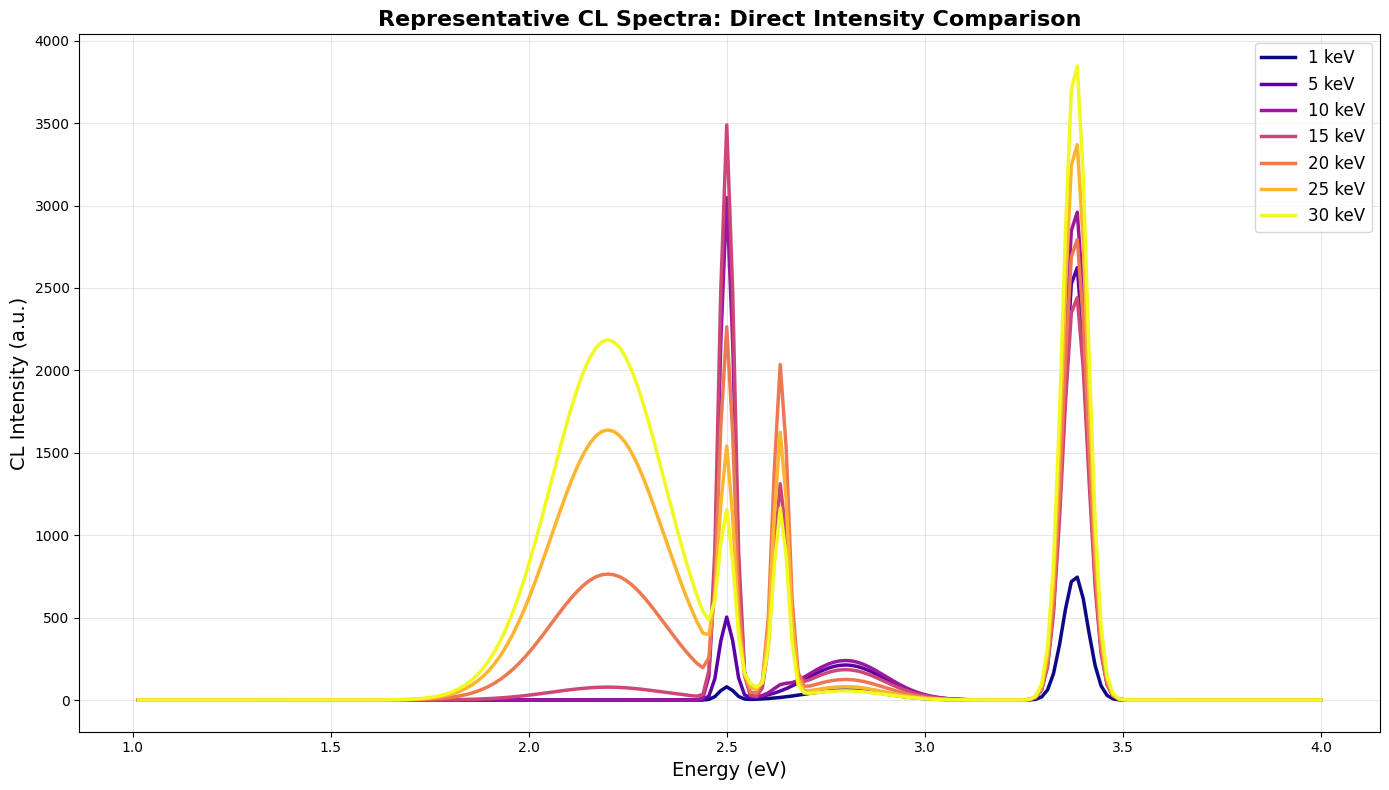

In [26]:
fig, ax = plt.subplots(figsize=(14, 8))

# Select key representative spectra (1, 5, 10, 15, 20, 25, 30 keV)
key_energies = [1, 5, 10, 15, 20, 25, 30]
key_indices = [e - 1 for e in key_energies]  # Convert to 0-based indices

# Use full plasma colormap for maximum color variation
colors = plt.cm.plasma(np.linspace(0, 1, len(key_indices)))

for i, idx in enumerate(key_indices):
    beam_energy = beam_energies[idx]
    
    # Plot spectrum without offset
    ax.plot(energy, spectra[:, idx], 
           color=colors[i], linewidth=2.5, 
           label=f'{beam_energy} keV')

ax.set_xlabel('Energy (eV)', fontsize=14)
ax.set_ylabel('CL Intensity (a.u.)', fontsize=14)
ax.set_title('Representative CL Spectra: Direct Intensity Comparison', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

## Heat Map Visualization of All Spectra

2D visualization showing intensity vs energy vs beam energy for the complete dataset.

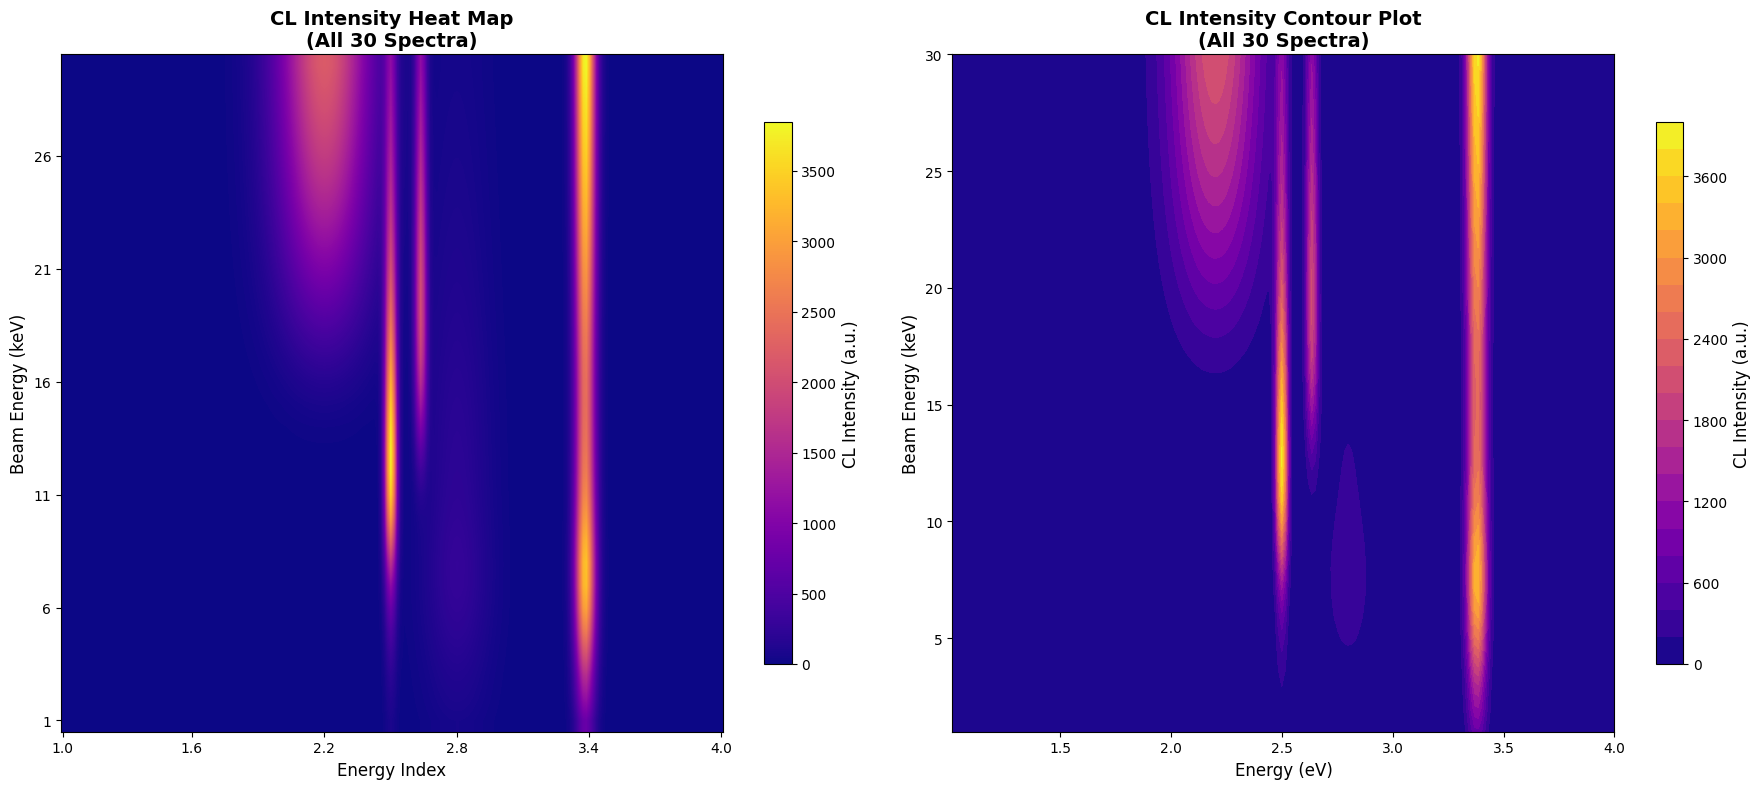

In [27]:
# Create 2D heat map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Heat map using imshow
im1 = ax1.imshow(spectra.T, aspect='auto', origin='lower', 
                cmap='plasma', interpolation='bilinear')

# Set up axes for heat map
ax1.set_xlabel('Energy Index', fontsize=12)
ax1.set_ylabel('Beam Energy (keV)', fontsize=12)
ax1.set_title('CL Intensity Heat Map\n(All 30 Spectra)', fontsize=14, fontweight='bold')

# Convert energy indices to actual energy values for x-axis labels
energy_ticks = np.linspace(0, len(energy)-1, 6, dtype=int)
energy_labels = [f'{energy[i]:.1f}' for i in energy_ticks]
ax1.set_xticks(energy_ticks)
ax1.set_xticklabels(energy_labels)

# Set y-axis to show beam energies
beam_ticks = np.arange(0, 30, 5)
ax1.set_yticks(beam_ticks)
ax1.set_yticklabels([f'{beam_energies[i]}' for i in beam_ticks])

# Add colorbar
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
cbar1.set_label('CL Intensity (a.u.)', fontsize=12)

# Contour plot for alternative visualization
X, Y = np.meshgrid(energy, beam_energies)
contour = ax2.contourf(X, Y, spectra.T, levels=20, cmap='plasma')

ax2.set_xlabel('Energy (eV)', fontsize=12)
ax2.set_ylabel('Beam Energy (keV)', fontsize=12)
ax2.set_title('CL Intensity Contour Plot\n(All 30 Spectra)', fontsize=14, fontweight='bold')

# Add colorbar for contour plot
cbar2 = plt.colorbar(contour, ax=ax2, shrink=0.8)
cbar2.set_label('CL Intensity (a.u.)', fontsize=12)

plt.tight_layout()
plt.show()

## Summary

This analysis provides multiple perspectives on the CL spectral evolution:

1. **Waterfall Plots**: Show clear spectral evolution trends with beam energy in both low (1-15 keV) and high (15-30 keV) energy ranges
2. **Representative Spectra**: Highlight key changes at important beam energies
3. **Heat Maps**: Provide a comprehensive 2D view of the entire dataset, revealing patterns and correlations

The visualization reveals how CL spectral features evolve with excitation beam energy, which is crucial for understanding the depth-dependent luminescence properties of the material.